# Analyzing Sentiments and Quality in Reviews from the ICLR2025 Dataset

## Load the dataset

In [1]:
import pandas as pd

df = pd.read_json("hf://datasets/babytreecc/ICLR2025review/papers_with_reviews.json")

## Analyze the statistics of the dataset

In [2]:
df.head()

,id,title,track,status,keywords,primary_area,author,authorids,aff,aff_domain,...,presentation,rating_avg,confidence_avg,soundness_avg,contribution_avg,presentation_avg,corr_rating_confidence,project,github,Review
0,00SnKBGTsz,DataEnvGym: Data Generation Agents in Teacher ...,main,Active,iterative data generation;llm agent;lifelong l...,"foundation or frontier models, including LLMs",,,,,...,3;3;2;2,6.25,3.75,2.75,3.25,2.50,0.132453,,,[{'summary': {'value': 'This paper introduces ...
1,00ezkB2iZf,MedFuzz: Exploring the Robustness of Large Lan...,main,Active,large language model;adversarial machine learn...,"foundation or frontier models, including LLMs",,,,,...,3;2;3;3,4.25,4.00,2.75,2.75,2.75,-0.272166,,,[{'summary': {'value': 'This paper investigate...
2,01wMplF8TL,INSTRUCTION-FOLLOWING LLMS FOR TIME SERIES PRE...,main,Active,Large Language Models;Time-series Prediction;M...,learning on time series and dynamical systems,,,,,...,1;3;3;2,4.50,3.25,2.25,2.50,2.25,0.333333,,,[{'summary': {'value': 'The article describe a...
3,029hDSVoXK,Dynamic Neural Fortresses: An Adaptive Shield ...,main,Active,Model Extraction Defense,"alignment, fairness, safety, privacy, and soci...",,,,,...,2;2;2;3;3,5.00,3.40,2.60,2.80,2.40,-0.179029,,,[{'summary': {'value': 'The paper presents “Dy...
4,02DCEU6vSU,Gen-LRA: Towards a Principled Membership Infer...,main,Active,Privacy;Membership Inference Attacks;Generativ...,"alignment, fairness, safety, privacy, and soci...",,,,,...,3;3;3;3;3,4.80,3.80,2.40,2.40,3.00,-0.054554,,,[{'summary': {'value': 'The paper describes a ...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      11856 non-null  object 
 1   title                   11856 non-null  object 
 2   track                   11856 non-null  object 
 3   status                  11856 non-null  object 
 4   keywords                11856 non-null  object 
 5   primary_area            11856 non-null  object 
 6   author                  11856 non-null  object 
 7   authorids               11856 non-null  object 
 8   aff                     11856 non-null  object 
 9   aff_domain              11856 non-null  object 
 10  position                11856 non-null  object 
 11  rating                  11856 non-null  object 
 12  confidence              11856 non-null  object 
 13  soundness               11856 non-null  object 
 14  contribution            11856 non-null

In [4]:
df.describe()

,rating_avg,confidence_avg,soundness_avg,contribution_avg,presentation_avg,corr_rating_confidence
count,11856.000000,11856.000000,11856.000000,11856.000000,11856.000000,11856.000000
mean,4.713283,3.608691,2.521943,2.299632,2.559896,-0.159491
std,1.139925,0.637133,0.505013,0.495917,0.548174,0.530734
min,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000
25%,4.000000,3.250000,2.250000,2.000000,2.250000,-0.577350
50%,4.750000,3.666667,2.500000,2.250000,2.666667,-0.080845
75%,5.500000,4.000000,2.800000,2.600000,3.000000,0.140028
max,9.000000,5.000000,4.000000,4.000000,4.000000,1.000000


## Check **`Review`** column for the entire review context

In [5]:
print(df['Review'].iloc[2])

[{'summary': {'value': 'The article describe a new model to incorporate textual information with a more traditional timeseries forecasting model. It does so by combining an embedding computed from the historical numerical data with an embedding computing from the textual information. The combined embedding is then used to generate the forecast.\n\nThe model is tested both on real-world data, where it shows competitive results, and on generated data, where it is shown to follow the instructions included in the textual information.'}, 'soundness': {'value': 3}, 'presentation': {'value': 2}, 'contribution': {'value': 3}, 'strengths': {'value': '1. It is good that zero shot examples of descriptions which have not been provided in the training set have been tested with. Without those, the narrow set of possible descriptions could have made it impossible to check whether the result quality came from the model overfitting on these descriptions or not.\n2. Training the model using generated da

## Extract the summary to be a new column

In [ ]:
def extract_summaries(review_list):
    return [entry.get('summary', {}).get('value', '') for entry in review_list]


df['Summaries'] = df['Review'].apply(extract_summaries)

# Flatten the summaries into a single string per row
df['Summaries_Flat'] = df['Summaries'].apply(lambda x: ' '.join(x))

print(df[['Summaries', 'Summaries_Flat']])

                                               Summaries  \
0      [This paper introduces Gym environments for da...   
1      [This paper investigates the robustness of lar...   
2      [The article describe a new model to incorpora...   
3      [The paper presents “Dynamic Neural Fortress” ...   
4      [The paper describes a membership inference at...   
...                                                  ...   
11851  [The paper proposes a novel Multimodal Represe...   
11852  [, , , , , , , , The authors analyze the gener...   
11853  [The paper proposes RAMP (Running away from th...   
11854  [, The authors present a method for batch cons...   
11855  [The paper proposes an algorithm that achieves...   

                                          Summaries_Flat  
0      This paper introduces Gym environments for dat...  
1      This paper investigates the robustness of larg...  
2      The article describe a new model to incorporat...  
3      The paper presents “Dynamic Neural F

## Handle missing values

In [ ]:
empty_summaries = df[df['Summaries_Flat'].str.strip() == '']
print(f"Number of empty summaries: {len(empty_summaries)}")


Number of empty summaries: 168


In [8]:
# Remove rows with empty summaries
df = df[df['Summaries_Flat'].str.strip() != '']


## Check the statistics of the content of reviews

In [ ]:
# Add a column for the length of summaries
df['Summary_Length'] = df['Summaries_Flat'].apply(len)
print(df['Summary_Length'].describe())


count    11688.000000
mean      2500.394849
std        868.321627
min        389.000000
25%       1925.000000
50%       2370.000000
75%       2906.250000
max      10907.000000
Name: Summary_Length, dtype: float64


In [ ]:
# Calculate word count for each summary
df['Word_Count'] = df['Summaries_Flat'].apply(lambda x: len(x.split()))
average_word_count = df['Word_Count'].mean()
print(f"Average Review Length (word count): {average_word_count:.2f}")


Average Review Length (word count): 352.29


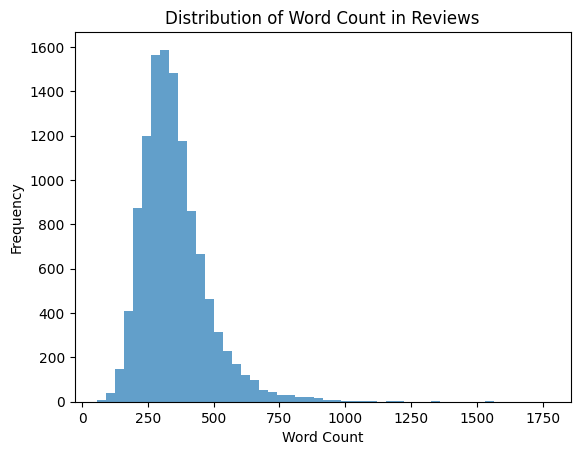

In [ ]:
import matplotlib.pyplot as plt

# Plot histogram of summary lengths
plt.hist(df['Word_Count'], bins=50, alpha=0.7)
plt.title("Distribution of Word Count in Reviews")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

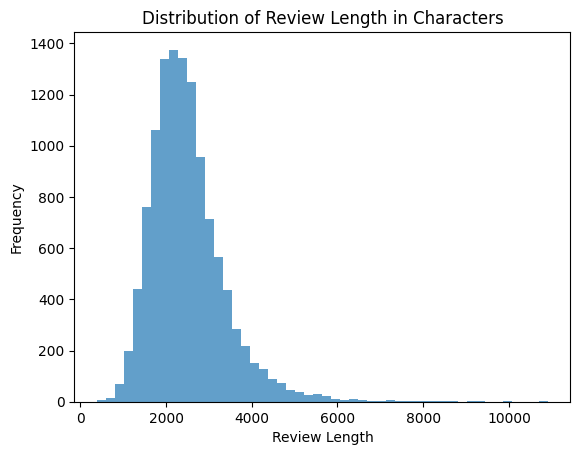

In [ ]:
# Plot histogram of summary lengths in characters
plt.hist(df['Summary_Length'], bins=50, alpha=0.7)
plt.title("Distribution of Review Length in Characters")
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.show()

## Sentiment Analysis

### Use base model(VADER) to do sentiment analysis

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()


def classify_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'


df['Sentiment_VADER'] = df['Summaries_Flat'].apply(classify_sentiment)
print(df[['Summaries_Flat', 'Sentiment_VADER']])


                                          Summaries_Flat Sentiment_VADER
0      This paper introduces Gym environments for dat...        positive
1      This paper investigates the robustness of larg...        negative
2      The article describe a new model to incorporat...        positive
3      The paper presents “Dynamic Neural Fortress” o...        positive
4      The paper describes a membership inference att...        positive
...                                                  ...             ...
11851  The paper proposes a novel Multimodal Represen...        positive
11852          The authors analyze the generalization...        negative
11853  The paper proposes RAMP (Running away from the...        positive
11854   The authors present a method for batch constr...        positive
11855  The paper proposes an algorithm that achieves ...        negative

[11688 rows x 2 columns]


In [14]:
df['Sentiment_VADER'].value_counts(normalize=True)

Sentiment_VADER
positive    0.873203
negative    0.119781
neutral     0.007016
Name: proportion, dtype: float64

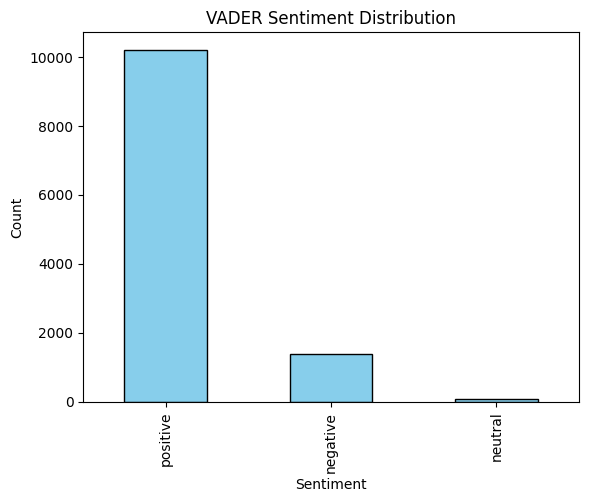

In [ ]:
df['Sentiment_VADER'].value_counts().plot(kind='bar', color='skyblue',
                                           edgecolor='black')
plt.title('VADER Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


In [ ]:
from transformers import pipeline


sentiment_pipeline = pipeline("sentiment-analysis", framework="pt",
                               truncation=True, max_length=512, device=0)

df['Sentiment_Transformers'] = df['Summaries_Flat'].apply(
    lambda x: sentiment_pipeline(x)[0]['label']
)

print(df[['Summaries_Flat', 'Sentiment_Transformers']])


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
C:\Users\XD\AppData\Roaming\Python\Python312\site-packages\transformers\models\distilbert\modeling_distilbert.py:403: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


                                          Summaries_Flat  \
0      This paper introduces Gym environments for dat...   
1      This paper investigates the robustness of larg...   
2      The article describe a new model to incorporat...   
3      The paper presents “Dynamic Neural Fortress” o...   
4      The paper describes a membership inference att...   
...                                                  ...   
11851  The paper proposes a novel Multimodal Represen...   
11852          The authors analyze the generalization...   
11853  The paper proposes RAMP (Running away from the...   
11854   The authors present a method for batch constr...   
11855  The paper proposes an algorithm that achieves ...   

      Sentiment_Transformers  
0                   POSITIVE  
1                   NEGATIVE  
2                   POSITIVE  
3                   NEGATIVE  
4                   NEGATIVE  
...                      ...  
11851               POSITIVE  
11852               NEGATIVE  


In [17]:
df['Sentiment_Transformers'].value_counts(normalize=True)

Sentiment_Transformers
POSITIVE    0.563398
NEGATIVE    0.436602
Name: proportion, dtype: float64

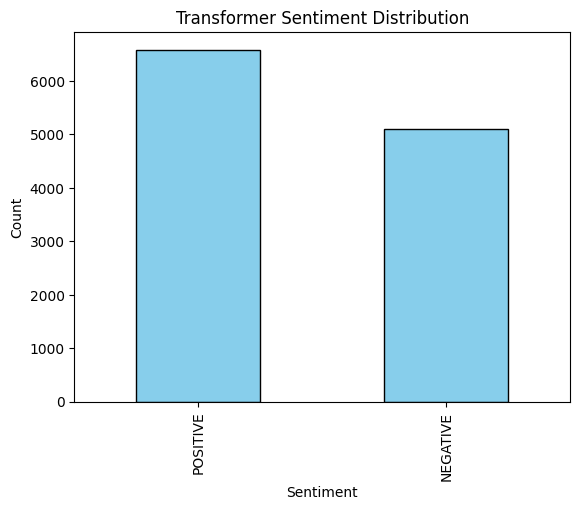

In [ ]:
df['Sentiment_Transformers'].value_counts().plot(kind='bar', color='skyblue',
                                                  edgecolor='black')
plt.title('Transformer Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


### Check the difference between VADER and Transformer

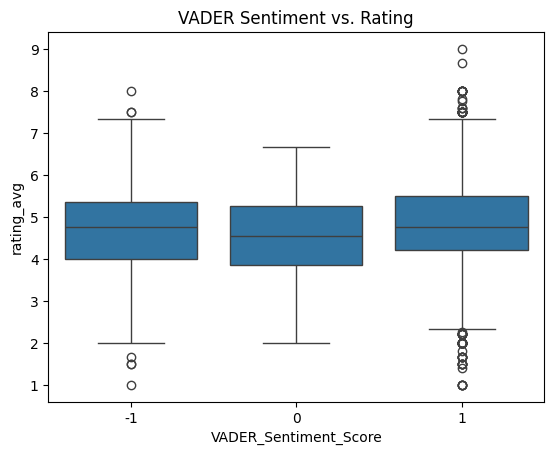

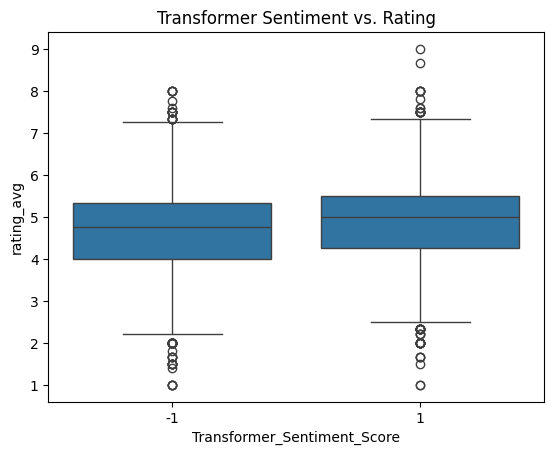

In [ ]:
import seaborn as sns

# Map sentiments to numeric scores (positive=1, neutral=0, negative=-1)
sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1,
                  'POSITIVE': 1, 'NEGATIVE': -1}
df['VADER_Sentiment_Score'] = df['Sentiment_VADER'].map(sentiment_map)
df['Transformer_Sentiment_Score'] = df['Sentiment_Transformers'].map(
    sentiment_map)

sns.boxplot(x='VADER_Sentiment_Score', y='rating_avg', data=df)
plt.title('VADER Sentiment vs. Rating')
plt.show()

sns.boxplot(x='Transformer_Sentiment_Score', y='rating_avg', data=df)
plt.title('Transformer Sentiment vs. Rating')
plt.show()


In [ ]:
# Calculate correlation
vader_corr = df[['VADER_Sentiment_Score', 'rating_avg']].corr().iloc[0, 1]
transformer_corr = df[[
    'Transformer_Sentiment_Score', 'rating_avg']].corr().iloc[0, 1]

print(f"VADER Correlation: {vader_corr}")
print(f"Transformer Correlation: {transformer_corr}")


VADER Correlation: 0.04569141032807413
Transformer Correlation: 0.10865730342878603


### Analyze sentiments by Transformer

#### Distribution of word counts in different groups

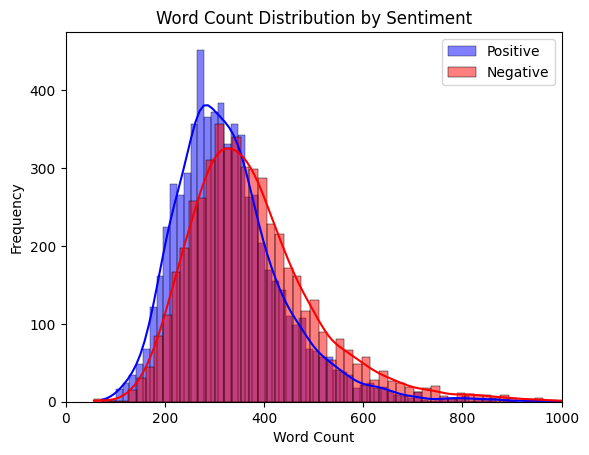

In [ ]:
positive_reviews = df[df['Sentiment_Transformers'] == 'POSITIVE']
negative_reviews = df[df['Sentiment_Transformers'] == 'NEGATIVE']

# Plot word count distribution
sns.histplot(positive_reviews['Word_Count'], color='blue',
              label='Positive', kde=True, alpha=0.5)
sns.histplot(negative_reviews['Word_Count'], color='red',
              label='Negative', kde=True, alpha=0.5)
plt.title("Word Count Distribution by Sentiment")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.xlim(0, 1000)
plt.legend()
plt.show()

#### Find most frequent words in different sentiments

In [ ]:
from collections import Counter
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


def get_most_common_words(reviews, n=100):
    all_words = ' '.join(reviews).split()
    filtered_words = [
        word.lower() for word in all_words if word.lower() not in stop_words]
    return Counter(filtered_words).most_common(n)


positive_words = get_most_common_words(positive_reviews['Summaries_Flat'])
negative_words = get_most_common_words(negative_reviews['Summaries_Flat'])


print("Most common words in positive reviews:", positive_words)
print("Most common words in negative reviews:", negative_words)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\XD\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Most common words in positive reviews: [('paper', 26947), ('authors', 15002), ('model', 12734), ('method', 12001), ('models', 9004), ('introduces', 7695), ('proposed', 7691), ('data', 7418), ('learning', 7380), ('performance', 7078), ('using', 7002), ('proposes', 6914), ('approach', 6896), ('framework', 5968), ('results', 5864), ('experiments', 5605), ('novel', 5448), ('training', 5261), ('new', 5074), ('across', 4878), ('based', 4633), ('propose', 4504), ('language', 4413), ('show', 4250), ('also', 4249), ('methods', 4202), ('demonstrate', 4201), ('presents', 4183), ('existing', 4068), ('different', 3964), ('two', 3776), ('neural', 3533), ('work', 3526), ('diffusion', 3467), ('image', 3434), ('large', 3229), ('tasks', 3188), ('various', 3095), ('graph', 3069), ('effectiveness', 3018), ('dataset', 2988), ('generation', 2874), ('experimental', 2813), ('multiple', 2754), ('datasets', 2708), ('improve', 2690), ('tasks.', 2626), ('models.', 2611), ('information', 2531), ('compared', 2509),

In [58]:
# Convert the word lists to sets for easy comparison
positive_word_set = set(word for word, _ in positive_words)
negative_word_set = set(word for word, _ in negative_words)

# Words unique to positive and negative reviews
unique_positive_words = positive_word_set - negative_word_set
unique_negative_words = negative_word_set - positive_word_set

print("Words unique to positive reviews:", unique_positive_words)
print("Words unique to negative reviews:", unique_negative_words)


Words unique to positive reviews: {'latent', 'traditional', 'including', 'methods.', 'achieves', 'prediction', 'key', 'extensive', 'representation', 'within', 'outperforms', 'feature', 'previous', '3d', 'enhance', 'addresses'}
Words unique to negative reviews: {'one', 'shows', 'evaluation', 'function', 'evaluate', 'provide', 'reward', 'set', 'trained', 'generated', 'number', 'given', 'distribution', 'studies', 'study', 'reasoning'}


## Review quality prediction

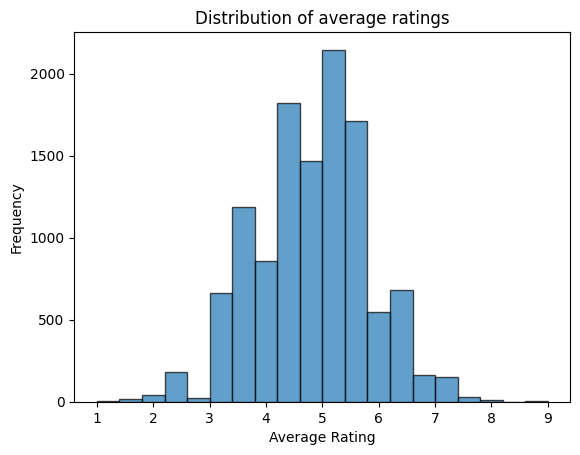

In [21]:
import matplotlib.pyplot as plt

plt.hist(df['rating_avg'], bins=20, edgecolor='k', alpha=0.7)
plt.title('Distribution of average ratings')
plt.xlabel('Average Rating')
plt.ylabel('Frequency')
plt.show()


### Feature engineering

#### Correlation heatmap

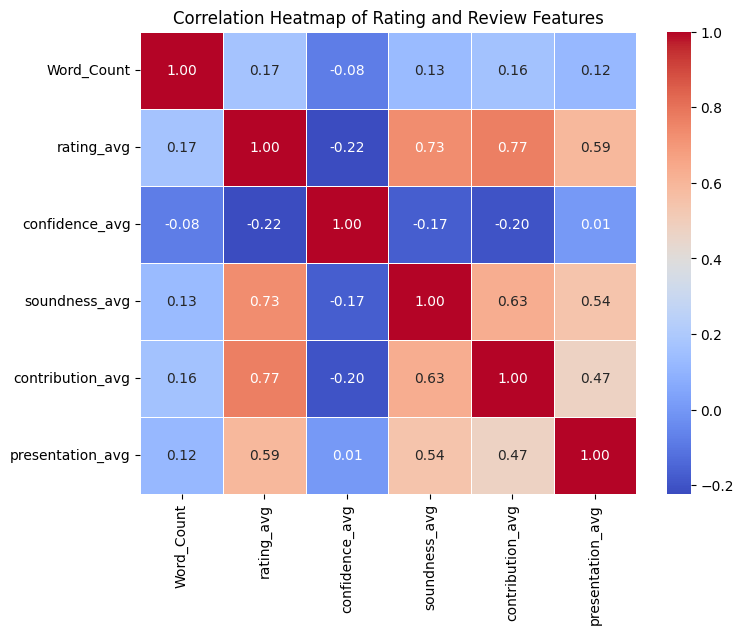

In [ ]:
correlation_matrix = df[['Word_Count', 'rating_avg', 'confidence_avg',
                         'soundness_avg', 'contribution_avg',
                         'presentation_avg']].corr()

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',
             fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Rating and Review Features')
plt.show()


#### Mutual information

In [ ]:
from sklearn.feature_selection import mutual_info_regression

# Calculate mutual information between predictors and the target
predictors = ['Word_Count', 'confidence_avg', 'soundness_avg',
               'contribution_avg', 'presentation_avg']
mi = mutual_info_regression(df[predictors], df['rating_avg'])

for feature, score in zip(predictors, mi):
    print(f"Mutual Information between {feature} and rating_avg: {score}")


Mutual Information between Word_Count and rating_avg: 0.11649834329193354
Mutual Information between confidence_avg and rating_avg: 0.4602054994376088
Mutual Information between soundness_avg and rating_avg: 0.8141973931625435
Mutual Information between contribution_avg and rating_avg: 0.9112803603098163
Mutual Information between presentation_avg and rating_avg: 0.6446161921639035


### Train models to do average rating prediction

In [43]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#### Baseline model(Mean)

In [ ]:
X = df[['confidence_avg', 'soundness_avg',
         'contribution_avg', 'presentation_avg']]
y = df['rating_avg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

mean_pred = y_train.mean()
baseline_pred = [mean_pred] * len(y_test)


baseline_mse = mean_squared_error(y_test, baseline_pred)

print(f"Baseline Model MSE (Mean): {baseline_mse:.2f}")

Baseline Model MSE (Mean): 1.02


#### Ridge model

In [ ]:
from sklearn.linear_model import Ridge

X = df[['Word_Count', 'confidence_avg', 'soundness_avg',
         'contribution_avg', 'presentation_avg']]
y = df['rating_avg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


regressor = Ridge()
regressor.fit(X_train, y_train)


lr_pred = regressor.predict(X_test)
mse = mean_squared_error(y_test, lr_pred)
print(f"Ridge MSE: {mse:.2f}")


Linear Regression MSE: 0.29


##### Tune the model

In [66]:
from sklearn.model_selection import GridSearchCV

param_grid = {'alpha': [0.1, 1, 10, 100]}
ridge = Ridge()
grid_search = GridSearchCV(ridge, param_grid, cv=5,
                           scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

best_ridge = grid_search.best_estimator_
print(f"Best Ridge alpha: {grid_search.best_params_}")
ridge_pred = best_ridge.predict(X_test)
print(f"Ridge Regression MSE: {mean_squared_error(y_test, ridge_pred):.2f}")


Best Ridge alpha: {'alpha': 1}
Ridge Regression MSE: 0.29


#### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

X = df[['Word_Count', 'confidence_avg', 'soundness_avg',
        'contribution_avg', 'presentation_avg']]
y = df['rating_avg']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
rf_pred = model.predict(X_test)

mse = mean_squared_error(y_test, rf_pred)
print(f"Random Forest MSE: {mse:.2f}")

Random Forest MSE: 0.34


##### Tune the model

In [ ]:
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 4],
    'max_features': ['log2', 'sqrt']
}


grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Best parameters and score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best MSE: {-grid_search.best_score_:.2f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best MSE: 0.28


#### Support Vector Machine(SVM)

In [ ]:
from sklearn.svm import SVR

X = df[['Word_Count', 'confidence_avg', 'soundness_avg',
         'contribution_avg', 'presentation_avg']]
y = df['rating_avg']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
model.fit(X_train, y_train)
svm_pred = model.predict(X_test)

mse = mean_squared_error(y_test, svm_pred)
print(f"SVM MSE: {mse:.2f}")

SVM MSE: 0.93


##### Tune the model

In [51]:
param_grid = {
    'kernel': ['rbf'],
    'C': [1, 10, 100],
    'epsilon': [0.1, 0.5, 1.0],
    'gamma': ['scale']
}

grid_search = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Best parameters and score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best MSE: {-grid_search.best_score_:.2f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Parameters: {'C': 100, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Best MSE: 0.31


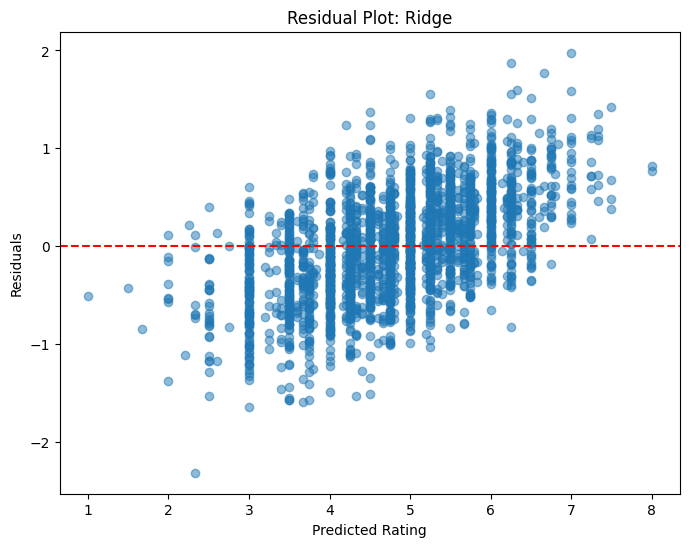

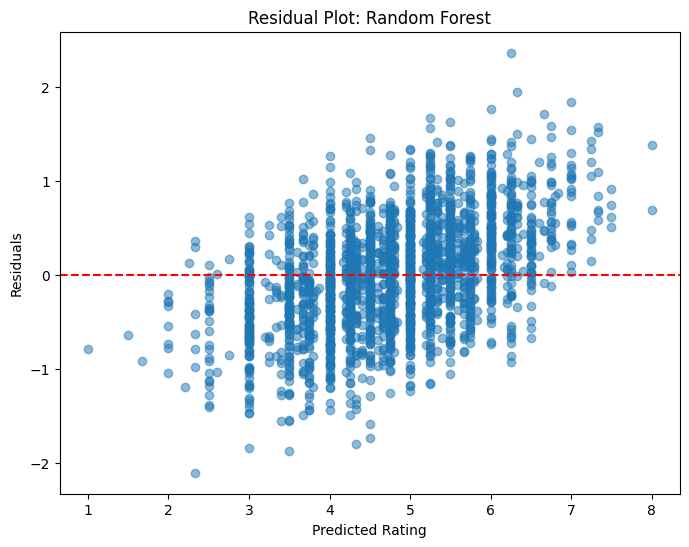

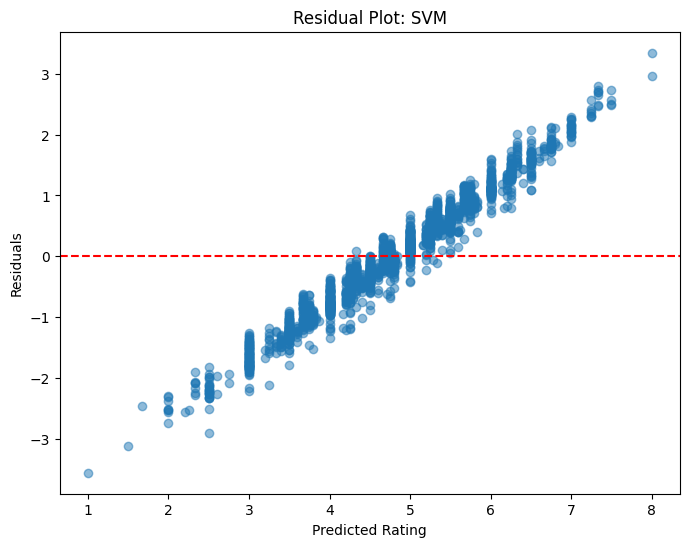

In [ ]:
# Residuals for each model
residuals_lr = (y_test - lr_pred)
residuals_rf = (y_test - rf_pred)
residuals_svm = (y_test - svm_pred)

# Residual Plot for each model
models = {'Ridge': residuals_lr,
          'Random Forest': residuals_rf,
          'SVM': residuals_svm}

for model_name, residuals in models.items():
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f"Residual Plot: {model_name}")
    plt.xlabel("Predicted Rating")
    plt.ylabel("Residuals")
    plt.show()


In [ ]:
residuals_df = pd.DataFrame({
    'Ridge': residuals_lr,
    'Random Forest': residuals_rf,
    'SVM': residuals_svm
})


print(residuals_df.describe())

             Ridge  Random Forest          SVM
count  2338.000000    2338.000000  2338.000000
mean      0.012443       0.012726     0.003866
std       0.538642       0.579436     0.967078
min      -2.314384      -2.105000    -3.561752
25%      -0.362872      -0.383250    -0.649792
50%       0.011886       0.017917     0.004812
75%       0.371767       0.393458     0.667690
max       1.977255       2.363333     3.347242
